In [1]:
%load_ext autoreload
%autoreload 2

In [73]:
import numpy
import torch

from matplotlib import pyplot
from tqdm.auto import tqdm, trange

from tiffwrapper import make_composite

In [74]:
from stedfm import get_pretrained_model_v2
from stedfm.models.classifier import MetaLinearProbe

from stedfm.datasets.multichannel import get_dataset

model, cfg = get_pretrained_model_v2(
    name="mae-mcms-token-lightning-small",
    weights="MAE_MCMS_TOKEN_SMALL_STED",
    as_classifier=True,
    classifier_type=MetaLinearProbe
)

CLASSES = None
NUM_CHANNELS = 2
dataset = get_dataset("pysoda", cfg, cache=False, classes=CLASSES)
print(f"Dataset length: {len(dataset)}")

classifier_type <class 'stedfm.models.classifier.MetaLinearProbe'>
in_channels 1
--- mae-lightning-small | (https://s3.valeria.science/flclab-foundation-models/models/mae-small-sted.zip) Downloading from URL and extracting zip ---

Loading state_dict from /home-local2/projects/SSL/baselines/mae-small_STED/pl_checkpoint-999.pth
--- mae-mcms-token-lightning-small | (/home-local2/projects/SSL/baselines/mae-mcms-token-small_STED/current_model.pth) Loading from local file ---

--- Loaded model mae-mcms-token-lightning-small with weights MAE_MCMS_TOKEN_SMALL_STED ---
--- Adding linear probe on top of mae-mcms-token-lightning-small ---
--- Added linear probe to all frozen blocks ---
Detected classes:  ['Homer-PSD95-Block', 'Homer-Bassoon-Block', 'Bassoon-PSD95-Block', 'Rim-Bassoon-Block']
Dataset length: 60


In [75]:
attention_maps = []
def grab_attention_forward_hook(module, input, output):
    """
    Attention has to be calculated in the forward pass, we recalculate it here and store
    """
    global attention_maps
    
    anchor_tokens, other_channels_list = input

    B, N_tokens, C = anchor_tokens.shape
    
    # 1. Concatenate all non-anchor channels along the token (sequence) dimension
    # Resulting shape: [B, 197 * (N-1), embed_dim]
    kv_context = torch.cat(other_channels_list, dim=1) 
    
    # 2. Project to Q, K, V matrices
    Q = module.q_proj(anchor_tokens)  # [B, 197, C]
    K = module.k_proj(kv_context)     # [B, 197 * (N-1), C]
    V = module.v_proj(kv_context)     # [B, 197 * (N-1), C]

    # 3. Reshape for Multi-Head Attention
    Q = Q.reshape(B, N_tokens, module.num_heads, module.head_dim).permute(0, 2, 1, 3)
    K = K.reshape(B, -1, module.num_heads, module.head_dim).permute(0, 2, 1, 3)
    V = V.reshape(B, -1, module.num_heads, module.head_dim).permute(0, 2, 1, 3)

    # 4. Compute Scaled Dot-Product Attention
    # Attention map shape: [B, num_heads, 197, 197 * (N-1)]
    attn = (Q @ K.transpose(-2, -1)) * module.scale
    attn = attn.softmax(dim=-1)

    # Store the attention map for later visualization
    attention_maps.append(attn.detach().cpu())

# Clear any registered hooks before registering new ones
for name, module in model.named_modules():
    if hasattr(module, "_forward_hooks") and module._forward_hooks:
        module._forward_hooks.clear()
        print(f"Cleared hooks from {name}")

# Register the forward hook to the attention layer of the model
# Assuming the attention layer is named 'cross_attn' in the model architecture
for name, module in model.named_modules():
    if name.endswith("cross_attn"):
        module.register_forward_hook(grab_attention_forward_hook)
        print(f"Registered forward hook to {name}")

# Print the registered hooks to verify
for name, module in model.named_modules():
    if hasattr(module, "_forward_hooks") and module._forward_hooks:
        print(f"Module {name} has hooks: {module._forward_hooks}")


Registered forward hook to backbone.fusion_module.cross_attn
Module backbone.fusion_module.cross_attn has hooks: OrderedDict([(1, <function grab_attention_forward_hook at 0x7fa5defc5b40>)])


In [76]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"
model.to(device)

attention_maps = []
for idx in trange(len(dataset)):
    image, metadata = dataset[idx]
    image = image.to(device)
    pixel_size = metadata.get("pixel_size", 0.015)
    with torch.no_grad():
        features = model.forward_features(image.unsqueeze(0), pixel_size=pixel_size)

# Group attention maps by images
grouped_attention_maps = {}
for idx in range(len(attention_maps)):
    image_id = idx // NUM_CHANNELS
    if image_id not in grouped_attention_maps:
        grouped_attention_maps[image_id] = []
    grouped_attention_maps[image_id].append(attention_maps[idx])

  0%|          | 0/60 [00:00<?, ?it/s]

60
(1, 6, 197, 197)


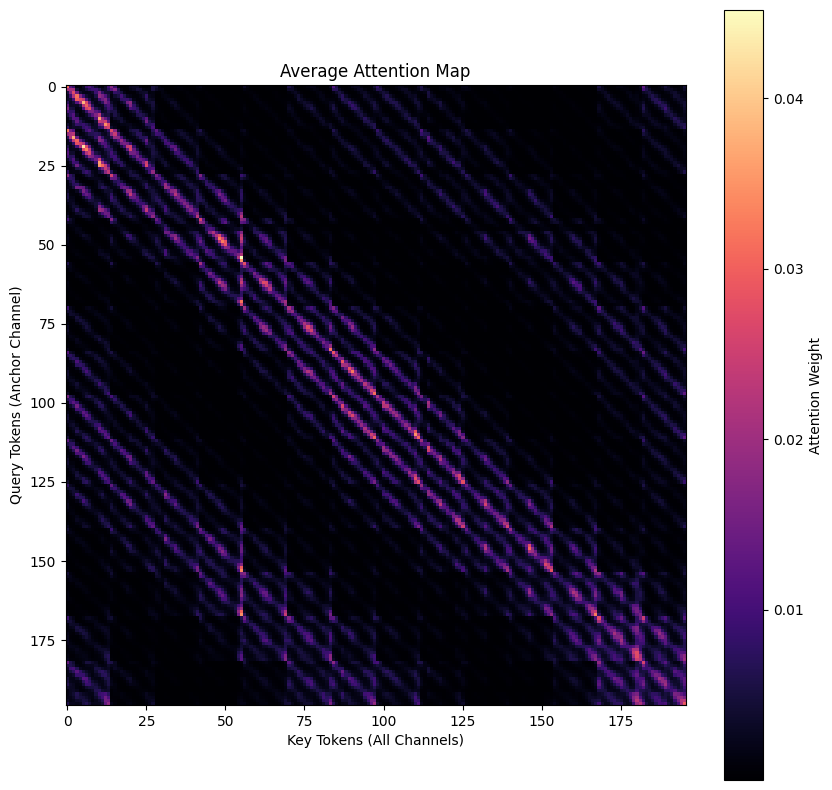

In [77]:
print(len(grouped_attention_maps))
attn_map = attention_maps[0].numpy()
print(attn_map.shape)

# Plot a single attention map
fig, ax = pyplot.subplots(figsize=(10, 10))
attn_map = numpy.mean(attn_map, axis=(0, 1))  # Average over batch and heads
attn_map = attn_map[1:, 1:]
pyplot.imshow(attn_map, cmap="magma")
pyplot.colorbar(label="Attention Weight")
pyplot.title("Average Attention Map")
pyplot.xlabel("Key Tokens (All Channels)")
pyplot.ylabel("Query Tokens (Anchor Channel)")
pyplot.show()

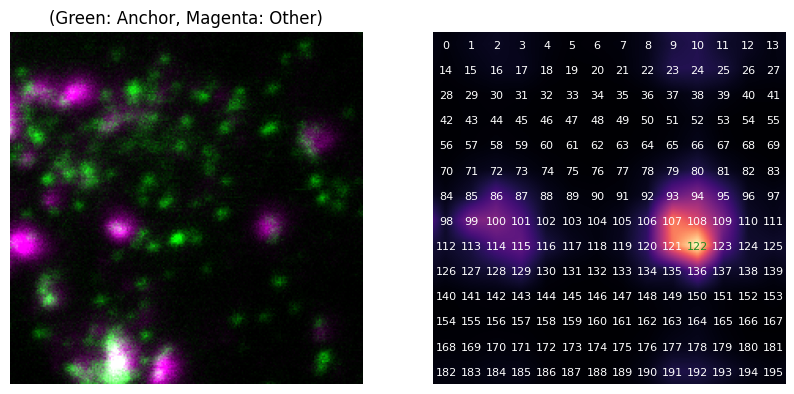

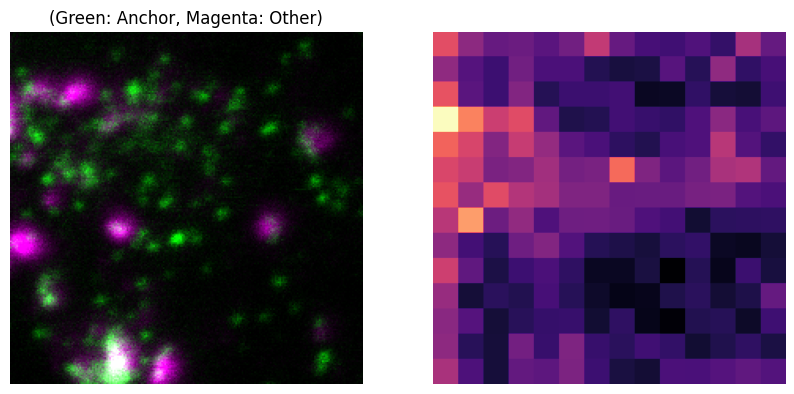

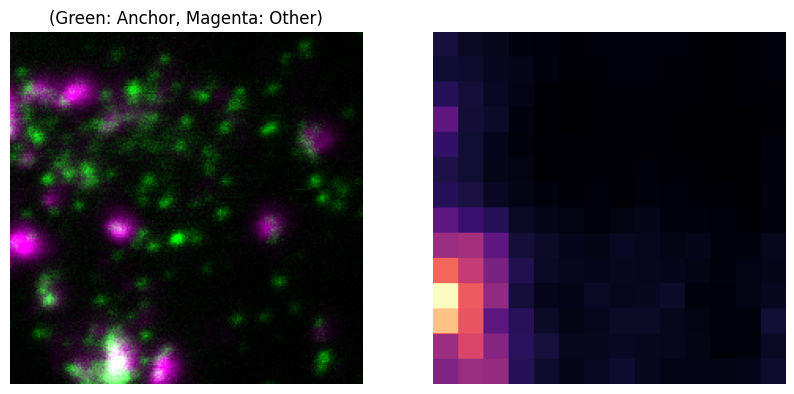

In [72]:
from skimage.transform import resize

image_id = 48  # Example image ID
image, _ = dataset[image_id]
image = image.cpu().numpy()

quantiles = numpy.quantile(image, [0.0, 0.995], axis=(-2, -1))
composite_image = make_composite(image, luts=["green", "magenta"], ranges=quantiles.T)

# Plot how the attention map of a patch attends to all other patches in the other channel
query_patch_idx = 122  # Example patch index in the anchor channel

attn_map = grouped_attention_maps[image_id][0].numpy()
attn_map = numpy.mean(attn_map, axis=(0, 1))  # Average over batch and heads
attn_map = attn_map[1:, 1:]
attn_weights = attn_map[query_patch_idx]  # Attention weights for the selected query patch
attn_map_reshaped = attn_weights.reshape(NUM_CHANNELS - 1, 14, 14)  # Reshape to separate channels
attn_map_reshaped = resize(attn_map_reshaped[0], image.shape[-2:], anti_aliasing=True)  # Resize to match the anchor channel size

fig, axes = pyplot.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(composite_image)
axes[1].imshow(attn_map_reshaped, cmap="magma")  # Plot attention to the first other channel
axes[0].set_title("(Green: Anchor, Magenta: Other)")
# axes[1].set_title(f"Attention from Patch {query_patch_idx} to Other Channels")
for ax in axes:
    ax.axis("off")
patch_size = 16
for i in range(14):
    for j in range(14):
        color = "forestgreen" if (j + i * 14) == query_patch_idx else "white"
        axes[1].text(
            j * patch_size + patch_size // 2, i * patch_size + patch_size // 2,
            f"{j + i * 14}", ha="center", va="center", color=color, fontsize=8)

pyplot.show()

# average attention map across all query patches
average_attn_weights = numpy.mean(attn_map, axis=0)  # Average over query patches
average_attn_reshaped = average_attn_weights.reshape(NUM_CHANNELS - 1, 14, 14)  # Reshape to separate channels
average_attn_reshaped = resize(average_attn_reshaped[0], image.shape[-2:], anti_aliasing=True, order=0)  # Resize to match the anchor channel size   

fig, axes = pyplot.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(composite_image)
axes[1].imshow(average_attn_reshaped, cmap="magma")
axes[0].set_title("(Green: Anchor, Magenta: Other)")
# axes[1].set_title("Average Attention from All Patches to Other Channels")
for ax in axes:
    ax.axis("off")
pyplot.show()

# Plot attention maps from the CLS token to all other patches in the other channel
cls_attn_weights = grouped_attention_maps[image_id][0].numpy()  # Attention weights for the CLS token
cls_attn_weights = numpy.mean(cls_attn_weights, axis=(0, 1))  # Average over batch and heads
cls_attn_weights = cls_attn_weights[0, 1:]  # CLS token attends to all other tokens
cls_attn_reshaped = cls_attn_weights.reshape(NUM_CHANNELS - 1, 14, 14)  # Reshape to separate channels
cls_attn_reshaped = resize(cls_attn_reshaped[0], image.shape[-2:], anti_aliasing=True, order=0)  # Resize to match the anchor channel size  

fig, axes = pyplot.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(composite_image)
axes[1].imshow(cls_attn_reshaped, cmap="magma")
axes[0].set_title("(Green: Anchor, Magenta: Other)")
# axes[1].set_title("Attention from CLS Token to Other Channels")
for ax in axes:
    ax.axis("off")
pyplot.show()